## Подготовка признаков

### Импорты

In [1]:
from functools import partial

import geopandas as gpd
import pandas as pd
from shapely import Point
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

from src.features.geo import extract_polygon
from src.plotting.plots import plot_iqr_boxplot_comparison
from src.preprocessing.preprocessing import construct_basin_location_mapper_with_external, onehot_encode, \
    split_binarize_encode, str_col_vals_to_lower, \
    col_names_to_lower, fill_with_unknown, fill_missing_coords, fill_missing_basins, calc_water_features, \
    calc_ref_features, \
    infer_basin_locations, map_basin_location, onehot_encode_test_data, \
    split_binarize_encode_test_data

### Загрузка данных

#### Обучающий и тестовый датасет

In [2]:
train_oil_df = pd.read_csv("../data/train_oil.csv")
test_oil_df = pd.read_csv("../data/oil_test.csv")

#### Пропущенные координаты, бассейны и мэппинг бассейнов

In [3]:
train_missing_coordinates = pd.read_csv("../data/train_missing_coordinates.csv")
test_missing_coordinates = pd.read_csv("../data/test_missing_coordinates.csv")

In [4]:
missing_basins = pd.read_csv("../data/missing_basins.csv")

In [5]:
basins_mapped = pd.read_csv("../data/basins_mapped.csv")
basins_mapped = basins_mapped.drop(basins_mapped[basins_mapped['basin_name'] == 'unknown'].index).reset_index(
    drop=True).to_dict("records")
external_basin_location_map = {b['basin_name']: b['location'] for b in basins_mapped}

#### Гео-датасеты

In [6]:
land = gpd.read_file("../data/ne_50m_land.zip")['geometry']
land_10m = gpd.read_file("../data/ne_10m_land.zip")['geometry']
ocean_50m = gpd.read_file("../data/ne_50m_ocean.zip")['geometry']
ocean_110m = gpd.read_file("../data/ne_110m_ocean.zip")['geometry']
ne_50m_geography_marine_polys = gpd.read_file("../data/ne_50m_geography_marine_polys.zip")
lakes = gpd.read_file("../data/ne_50m_lakes.zip")['geometry']
geography_regions = gpd.read_file("../data/ne_50m_geography_regions_polys.zip")
rivers_lake_centerlines = gpd.read_file("../data/ne_50m_rivers_lake_centerlines.zip")['geometry']
major_islands = gpd.read_file("../data/ne_50m_coastline.zip")['geometry']
minor_islands = gpd.read_file("../data/ne_10m_minor_islands.zip")['geometry']

### Подготовка данных

In [7]:
train_oil_df = train_oil_df.transform(str_col_vals_to_lower).transform(col_names_to_lower)
test_oil_df = test_oil_df.transform(str_col_vals_to_lower).transform(col_names_to_lower)

In [8]:
train_oil_df = train_oil_df.transform(fill_with_unknown, col='region').transform(fill_with_unknown, col='country')
test_oil_df = test_oil_df.transform(fill_with_unknown, col='region').transform(fill_with_unknown, col='country')

In [9]:
print(f"Пустых значений region в train: {train_oil_df.region.isna().sum()}")
print(f"Пустых значений country в train: {train_oil_df.country.isna().sum()}")
print(f"Пустых значений region в test: {test_oil_df.region.isna().sum()}")
print(f"Пустых значений country в test: {test_oil_df.country.isna().sum()}")

Пустых значений region в train: 0
Пустых значений country в train: 0
Пустых значений region в test: 0
Пустых значений country в test: 0


In [10]:
train_oil_df = train_oil_df.transform(fill_missing_coords, missing_coords_df=train_missing_coordinates)
test_oil_df = test_oil_df.transform(fill_missing_coords, missing_coords_df=test_missing_coordinates)

In [11]:
print(f"Пустых значений latitude в train: {train_oil_df.latitude.isna().sum()}")
print(f"Пустых значений longitude в train: {train_oil_df.longitude.isna().sum()}")
print(f"Пустых значений latitude в test: {test_oil_df.latitude.isna().sum()}")
print(f"Пустых значений longitude в test: {test_oil_df.longitude.isna().sum()}")

Пустых значений latitude в train: 0
Пустых значений longitude в train: 0
Пустых значений latitude в test: 0
Пустых значений longitude в test: 0


In [12]:
train_oil_df = train_oil_df.transform(fill_missing_basins, basin_locations_df=missing_basins)
test_oil_df = test_oil_df.transform(fill_missing_basins, basin_locations_df=missing_basins)

In [13]:
print(f"Пустых значений basin_name в train: {train_oil_df.basin_name.isna().sum()}")
print(f"Пустых значений basin_name в test: {test_oil_df.basin_name.isna().sum()}")

Пустых значений basin_name в train: 0
Пустых значений basin_name в test: 8


In [14]:
test_oil_df = test_oil_df.transform(fill_with_unknown, col='basin_name')
print(f"Пустых значений basin_name в test: {test_oil_df.basin_name.isna().sum()}")

Пустых значений basin_name в test: 0


#### Преобразование в гео датасет

In [15]:
train_gdf = gpd.GeoDataFrame(train_oil_df,
                             geometry=gpd.points_from_xy(train_oil_df.longitude, train_oil_df.latitude),
                             crs="EPSG:4326")
test_gdf = gpd.GeoDataFrame(test_oil_df,
                            geometry=gpd.points_from_xy(test_oil_df.longitude, test_oil_df.latitude),
                            crs="EPSG:4326")

#### Формирование подмножеств геопризнаков

In [16]:
bays = ne_50m_geography_marine_polys[ne_50m_geography_marine_polys.featurecla == 'bay']['geometry']
gulfs = ne_50m_geography_marine_polys[ne_50m_geography_marine_polys.featurecla == 'gulf']['geometry']
straits = ne_50m_geography_marine_polys[ne_50m_geography_marine_polys.featurecla == 'strait']['geometry']
channels = ne_50m_geography_marine_polys[ne_50m_geography_marine_polys.featurecla == 'channel']['geometry']
sounds = ne_50m_geography_marine_polys[ne_50m_geography_marine_polys.featurecla == 'sound']['geometry']
rivers = ne_50m_geography_marine_polys[ne_50m_geography_marine_polys.featurecla == 'river']['geometry']
isthmuses = geography_regions[geography_regions.FEATURECLA == 'Isthmus']['geometry']
deltas = geography_regions[geography_regions.FEATURECLA == 'Delta']['geometry']
coasts = geography_regions[geography_regions.FEATURECLA == 'Coast']['geometry']
lake_regions = geography_regions[geography_regions.FEATURECLA == 'Lake']['geometry']
islands = geography_regions[geography_regions.FEATURECLA.isin(['Island group', 'Island'])]['geometry']

In [17]:
bunyu_coords = Point(117.833, 3.5)
bunyu_island = gpd.GeoSeries(
    [extract_polygon(land_10m[land_10m.geometry.contains(bunyu_coords)].iloc[0], bunyu_coords)],
    crs="EPSG:4326"
)

In [18]:
all_lakes = gpd.GeoDataFrame(
    geometry=pd.concat([lakes, rivers_lake_centerlines, lake_regions], ignore_index=True),
    crs="EPSG:4326").dissolve()

In [19]:
all_islands = gpd.GeoDataFrame(
    geometry=pd.concat([islands, major_islands, minor_islands, bunyu_island], ignore_index=True),
    crs="EPSG:4326").dissolve()

In [20]:
water_feature_datasets = {
    "ocean_50m": ocean_50m,
    "all_islands": all_islands,
    "gulfs": gulfs,
    "straits": straits,
    "deltas": deltas,
    "bays": bays}

### Подготовка признаков

#### Корректировка названия стран

In [21]:
train_gdf.loc[train_gdf['country'] == 'norway /uk', 'country'] = 'uk /norway'
test_gdf.loc[test_gdf['country'] == 'norway /uk', 'country'] = 'uk /norway'

#### Корректировка координат Berri Hanifa

In [24]:
berri_hanifa_coords = (27.11, 49.6389)
berri_hanifa_idx = (train_gdf["field_name"] == "berri") & (train_gdf["reservoir_unit"] == "hanifa")
train_gdf.loc[berri_hanifa_idx, 'latitude'] = berri_hanifa_coords[0]
train_gdf.loc[berri_hanifa_idx, 'longitude'] = berri_hanifa_coords[1]

#### Добавление координат меcторождения Djeitun
На сайте https://sst-ts.com/wellhead-platform-zhdanov-a/ указано, что Джейтун входит в контрактный район Челекен и экплуатируется оператором Dragon Oil, что совпадает со значениями в датасете. Возьмём координаты Челекен.

In [25]:
cheleken_idx = train_gdf['field_name'] == 'cheleken'
djeitun_idx = test_gdf['field_name'] == 'djeitun'
test_gdf.loc[djeitun_idx, 'latitude'] = train_gdf.loc[cheleken_idx, 'latitude']
test_gdf.loc[djeitun_idx, 'longitude'] = train_gdf.loc[cheleken_idx, 'longitude']

#### Расчёт гео-признаков

In [26]:
train_gdf = calc_water_features(train_gdf, water_feature_datasets=water_feature_datasets)
test_gdf = calc_water_features(test_gdf, water_feature_datasets=water_feature_datasets)

In [27]:
water_cols = ['water_pct', 'is_in_water', 'is_on_island', 'is_in_gulf', 'is_in_strait', 'is_in_delta', 'is_in_bay']
print(f"Пустых значений в гео-признаках train:\n{train_gdf[water_cols].isna().sum()}")

Пустых значений в гео-признаках train:
water_pct       0
is_in_water     0
is_on_island    0
is_in_gulf      0
is_in_strait    0
is_in_delta     0
is_in_bay       0
dtype: int64


In [28]:
print(f"Пустых значений в гео-признаках test:\n{test_gdf[water_cols].isna().sum()}")

Пустых значений в гео-признаках test:
water_pct       0
is_in_water     0
is_on_island    0
is_in_gulf      0
is_in_strait    0
is_in_delta     0
is_in_bay       0
dtype: int64


#### Извлечение отметок onshore/offshore, lake из названий месторождения и бассейна

In [29]:
train_gdf = calc_ref_features(train_gdf)
test_gdf = calc_ref_features(test_gdf)

In [30]:
ref_cols = ['ref_onshore', 'ref_offshore', 'ref_lake']
print(f"Пустых значений в ref-признаках train:\n{train_gdf[ref_cols].isna().sum()}")
print(f"Пустых значений в ref-признаках test:\n{test_gdf[ref_cols].isna().sum()}")

Пустых значений в ref-признаках train:
ref_onshore     0
ref_offshore    0
ref_lake        0
dtype: int64
Пустых значений в ref-признаках test:
ref_onshore     0
ref_offshore    0
ref_lake        0
dtype: int64


#### Метки локаций бассейнов (расчётные и внешние)

In [31]:
basin_location, inferred_location_map = infer_basin_locations(train_gdf)
basin_location_map_combined = construct_basin_location_mapper_with_external(basin_location, external_basin_location_map)

train_gdf = map_basin_location(train_gdf,
                               inferred_basin_location_map=inferred_location_map,
                               basin_location_map_combined=basin_location_map_combined)
test_gdf = map_basin_location(test_gdf,
                              inferred_basin_location_map=inferred_location_map,
                              basin_location_map_combined=basin_location_map_combined)

In [32]:
basin_loc_cols = ['basin_location_inferred', 'basin_location_external']
print(f"Пустых значений в признаках расположения бассейнов train:\n{train_gdf[basin_loc_cols].isna().sum()}")
print(f"Пустых значений в признаках расположения бассейнов test:\n{test_gdf[basin_loc_cols].isna().sum()}")

Пустых значений в признаках расположения бассейнов train:
basin_location_inferred    0
basin_location_external    0
dtype: int64
Пустых значений в признаках расположения бассейнов test:
basin_location_inferred    0
basin_location_external    0
dtype: int64


### Разбивка и кодировка композитных признаков 

In [73]:
_onehot_encode = partial(onehot_encode, df=train_gdf)
_onehot_encode_test_data = partial(onehot_encode_test_data, df=test_gdf)

In [34]:
train_country_f, country_t = _onehot_encode(col='country')
train_region_f, region_t = _onehot_encode(col='region')
train_basin_name_f, basin_name_t = _onehot_encode(col='basin_name')
train_operator_company_f, operator_company_t = _onehot_encode(col='operator_company')
train_hydrocarbon_type_f, hydrocarbon_type_t = _onehot_encode(col='hydrocarbon_type')
train_reservoir_period_f, reservoir_period_t = _onehot_encode(col='reservoir_period')
train_lithology_f, lithology_t = _onehot_encode(col='lithology')
train_basin_location_inferred_f, basin_location_inferred_t = _onehot_encode(col='basin_location_inferred')
train_basin_location_external_f, basin_location_external_t = _onehot_encode(col='basin_location_external')

In [74]:
test_country_f = _onehot_encode_test_data(transformer=country_t, col='country')
test_region_f = _onehot_encode_test_data(transformer=region_t, col='region')
test_basin_name_f = _onehot_encode_test_data(transformer=basin_name_t, col='basin_name')
test_operator_company_f = _onehot_encode_test_data(transformer=operator_company_t, col='operator_company')
test_hydrocarbon_type_f = _onehot_encode_test_data(transformer=hydrocarbon_type_t, col='hydrocarbon_type')
test_reservoir_period_f = _onehot_encode_test_data(transformer=reservoir_period_t, col='reservoir_period')
test_lithology_f = _onehot_encode_test_data(transformer=lithology_t, col='lithology')
test_basin_location_inferred_f = _onehot_encode_test_data(transformer=basin_location_inferred_t,
                                                          col='basin_location_inferred')
test_basin_location_external_f = _onehot_encode_test_data(transformer=basin_location_external_t,
                                                          col='basin_location_external')

In [80]:
_split_binarize_encode = partial(split_binarize_encode, df=train_gdf)
_split_binarize_encode_test_data = partial(split_binarize_encode_test_data, df=test_gdf)

In [81]:
train_tectonic_regime_f, tectonic_regime_t = _split_binarize_encode(col='tectonic_regime')
train_structural_setting_f, structural_setting_t = _split_binarize_encode(col='structural_setting')

In [82]:
test_tectonic_regime_f = _split_binarize_encode_test_data(transformer=tectonic_regime_t, col='tectonic_regime')
test_structural_setting_f = _split_binarize_encode_test_data(transformer=structural_setting_t, col='structural_setting')

In [83]:
train_features = {"country": train_country_f.columns,
                  "region": train_region_f.columns,
                  "basin_name": train_basin_name_f.columns,
                  "operator_company": train_operator_company_f.columns,
                  "hydrocarbon_type": train_hydrocarbon_type_f.columns,
                  "reservoir_period": train_reservoir_period_f.columns,
                  "lithology": train_lithology_f.columns,
                  "basin_location_inferred": train_basin_location_inferred_f.columns,
                  "basin_location_external": train_basin_location_external_f.columns,
                  "tectonic_regime": train_tectonic_regime_f.columns,
                  "structural_setting": train_structural_setting_f.columns}
for feature_group, columns in train_features.items():
    result = any('unknown' in c for c in columns)
    if not result:
        print(f"{feature_group} does not contain unknown")

basin_name does not contain unknown
operator_company does not contain unknown
hydrocarbon_type does not contain unknown
reservoir_period does not contain unknown
lithology does not contain unknown
basin_location_inferred does not contain unknown
basin_location_external does not contain unknown
tectonic_regime does not contain unknown
structural_setting does not contain unknown


In [84]:
test_features = {"country": test_country_f.columns,
                 "region": test_region_f.columns,
                 "basin_name": test_basin_name_f.columns,
                 "operator_company": test_operator_company_f.columns,
                 "hydrocarbon_type": test_hydrocarbon_type_f.columns,
                 "reservoir_period": test_reservoir_period_f.columns,
                 "lithology": test_lithology_f.columns,
                 "basin_location_inferred": test_basin_location_inferred_f.columns,
                 "basin_location_external": test_basin_location_external_f.columns,
                 "tectonic_regime": test_tectonic_regime_f.columns,
                 "structural_setting": test_structural_setting_f.columns}
for feature_group, columns in test_features.items():
    result = any('unknown' in c for c in columns)
    if not result:
        print(f"{feature_group} does not contain unknown")

basin_name does not contain unknown
operator_company does not contain unknown
hydrocarbon_type does not contain unknown
reservoir_period does not contain unknown
lithology does not contain unknown
basin_location_inferred does not contain unknown
basin_location_external does not contain unknown
tectonic_regime does not contain unknown
structural_setting does not contain unknown


### Масштабирование числовых признаков

In [85]:
numeric_cols = ['depth', 'thickness_gross_average_ft', 'thickness_net_pay_average_ft', 'porosity', 'permeability']
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()

train_numeric = train_gdf[numeric_cols].copy()
test_numeric = test_gdf[numeric_cols].copy()

standard_scaler.fit(train_numeric)
minmax_scaler.fit(train_numeric)
robust_scaler.fit(train_numeric)

train_std_scaled = pd.DataFrame(standard_scaler.transform(train_numeric), columns=numeric_cols)
test_std_scaled = pd.DataFrame(standard_scaler.transform(test_numeric), columns=numeric_cols)

train_mm_scaled = pd.DataFrame(minmax_scaler.transform(train_numeric), columns=numeric_cols)
test_mm_scaled = pd.DataFrame(minmax_scaler.transform(test_numeric), columns=numeric_cols)

train_robust_scaled = pd.DataFrame(robust_scaler.transform(train_numeric), columns=numeric_cols)
test_robust_scaled = pd.DataFrame(robust_scaler.transform(test_numeric), columns=numeric_cols)

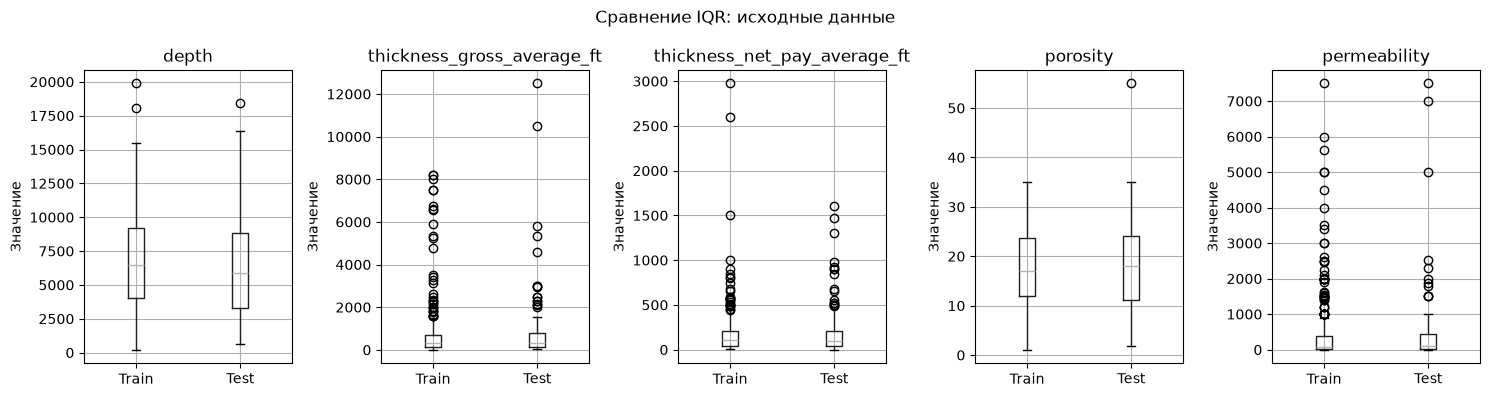

In [86]:
plot_iqr_boxplot_comparison(train_df=train_numeric, test_df=test_numeric, title="исходные данные")

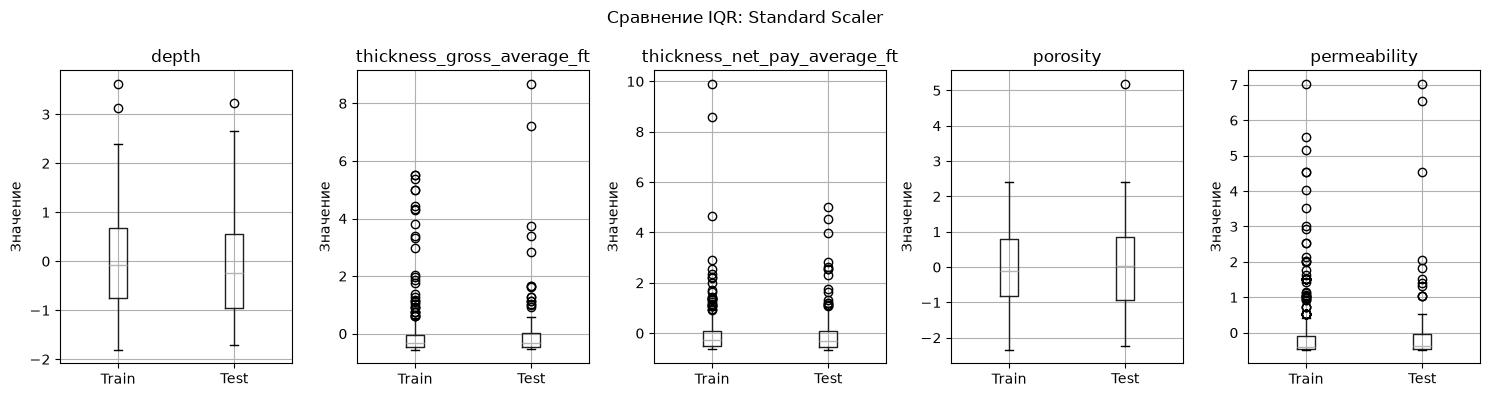

In [87]:
plot_iqr_boxplot_comparison(train_df=train_std_scaled, test_df=test_std_scaled, title="Standard Scaler")

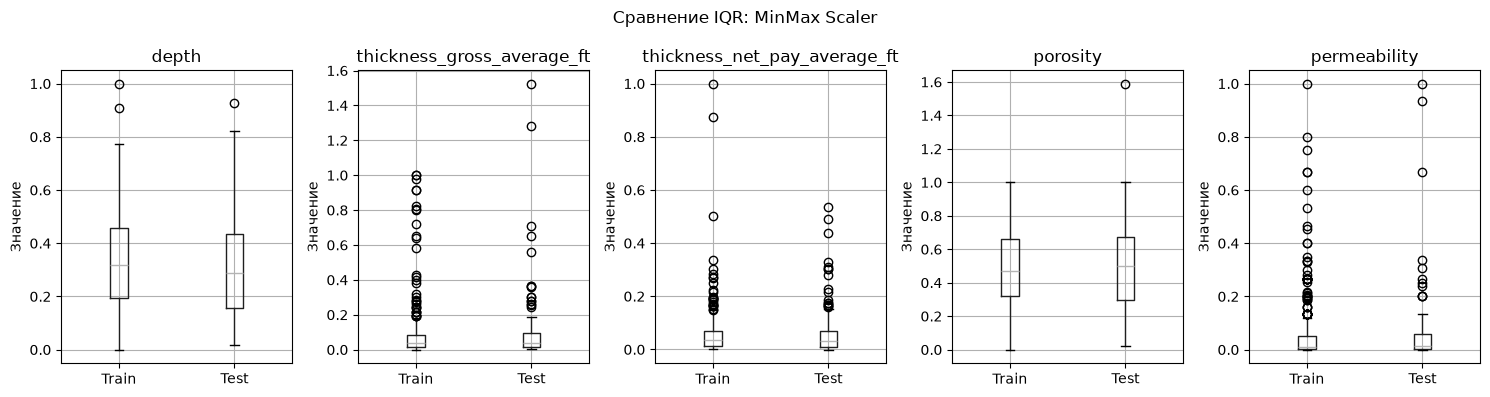

In [88]:
plot_iqr_boxplot_comparison(train_df=train_mm_scaled, test_df=test_mm_scaled, title="MinMax Scaler")

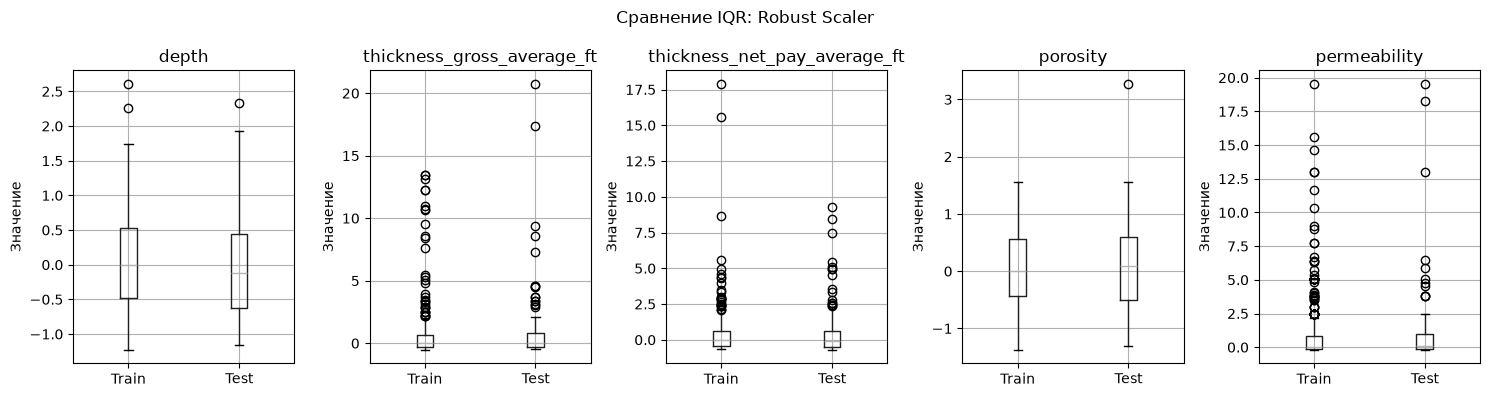

In [89]:
plot_iqr_boxplot_comparison(train_df=train_robust_scaled, test_df=test_robust_scaled, title="Robust Scaler")

В целом, выглядит, что больше всего подойдёт только масштабированные признаки по Min-Max. Все остальные имеют большой межквартильный разброс и могут снизить качество модели. 

### Конверсия бинарных признаков в целочисленные 

In [90]:
binary_cols = ['is_in_water', 'is_on_island', 'is_in_gulf', 'is_in_strait', 'is_in_delta', 'is_in_bay', 'ref_onshore',
               'ref_offshore', 'ref_lake']
train_binary_features = train_gdf[binary_cols].astype(float).copy()
test_binary_features = test_gdf[binary_cols].astype(float).copy()

### Сбор признаков

#### Catboost
Соберём признаки для Catboost. Catboost не требует OneHot-кодирования категориальных признаков и достаточно хорошо работает с немасштабированными признаками. 
Можно добавить категориальные признаки, как есть, за исключением признаков тектонического режима и структурной обстановки. Эти содержали несколько значений на одно наблюдение, следовательно, их пришлось разделить и закодировать.

In [96]:
catboost_feature_columns = ['country',
                            'region',
                            'basin_name',
                            'operator_company',
                            'hydrocarbon_type',
                            'reservoir_status',
                            'reservoir_period',
                            'lithology',
                            'basin_location_inferred',
                            'basin_location_external']

In [97]:
pd.concat([
    train_gdf[catboost_feature_columns],
    train_tectonic_regime_f,
    train_structural_setting_f,
    train_numeric,
    train_binary_features,
    train_gdf[['onshore_offshore']]
], axis=1).to_csv("../data/catboost_train_20260725.csv", index=False)

In [98]:
pd.concat([
    test_gdf[catboost_feature_columns],
    test_tectonic_regime_f,
    test_structural_setting_f,
    test_numeric,
    test_binary_features
], axis=1).to_csv("../data/catboost_test_20260725.csv", index=False)

#### Encoded
Сохраним закодированные признаки для других моделей.

In [107]:
encoded_train_dataset = pd.concat([
    train_country_f,
    train_region_f,
    train_basin_name_f,
    train_operator_company_f,
    train_hydrocarbon_type_f,
    train_reservoir_period_f,
    train_lithology_f,
    train_basin_location_inferred_f,
    train_basin_location_external_f,
    train_tectonic_regime_f,
    train_structural_setting_f,
    train_mm_scaled,
    train_binary_features,
    train_gdf[['onshore_offshore']]], axis=1)

In [108]:
encoded_train_dataset_na = encoded_train_dataset.isna().sum()
encoded_train_dataset_na_zero = (encoded_train_dataset_na > 0)
encoded_train_dataset_na[encoded_train_dataset_na_zero]

Series([], dtype: int64)

In [109]:
encoded_train_dataset.to_csv("../data/encoded_train_20260725.csv", index=False)

In [110]:
encoded_test_dataset = pd.concat([
    test_country_f,
    test_region_f,
    test_basin_name_f,
    test_operator_company_f,
    test_hydrocarbon_type_f,
    test_reservoir_period_f,
    test_lithology_f,
    test_basin_location_inferred_f,
    test_basin_location_external_f,
    test_tectonic_regime_f,
    test_structural_setting_f,
    test_mm_scaled,
    test_binary_features], axis=1)

In [111]:
encoded_test_dataset_na = encoded_test_dataset.isna().sum()
encoded_test_dataset_na_zero = (encoded_test_dataset_na > 0)
encoded_test_dataset_na[encoded_test_dataset_na_zero]

Series([], dtype: int64)

In [112]:
encoded_test_dataset.to_csv("../data/encoded_test_20260725.csv", index=False)